# Phase 1 — Project A: MLP Architecture Intuition

**Goal**: Stop treating hyperparameters as magic numbers. By the end of this notebook you will be able to look at a new tabular ML problem and make *justified* choices about MLP depth, width, dropout, and learning rate.

**Dataset**: House Prices (Ames Housing) — a regression problem with 79 mixed features (numeric + categorical). Messier than MNIST, closer to real work.

**What you will implement**:
- A flexible `MLP` class where you control every layer
- A preprocessing pipeline
- A training loop with proper logging
- An experiment runner for ablation studies
- Visualizations to interpret your results

**What you will NOT be given**:
- The depth, width, or dropout values — you will discover them
- A working `MLP` class — you will build it
- Experiment results — you will generate and explain them

---
## Setup

In [32]:
# Run this cell first — installs everything needed
# On Kaggle/Colab this is already available; on local env pip install as needed
# !pip install kaggle pandas numpy scikit-learn matplotlib seaborn wandb torch torchvision

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

import wandb
import itertools
import time
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: mps


---
## Section 1 — Load and explore the data

Download the data from Kaggle: https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data  
Place `train.csv` and `test.csv` in a `data/` folder next to this notebook.

Alternatively on Kaggle notebooks, the path is `/kaggle/input/house-prices-advanced-regression-techniques/`.

In [33]:
# Adjust path if running on Kaggle
DATA_DIR = Path('house-prices')

df_train = pd.read_csv(DATA_DIR / 'train.csv')
df_test  = pd.read_csv(DATA_DIR / 'test.csv')

print(f'Train shape: {df_train.shape}')
print(f'Test shape:  {df_test.shape}')
df_train.head(3)

Train shape: (1460, 81)
Test shape:  (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


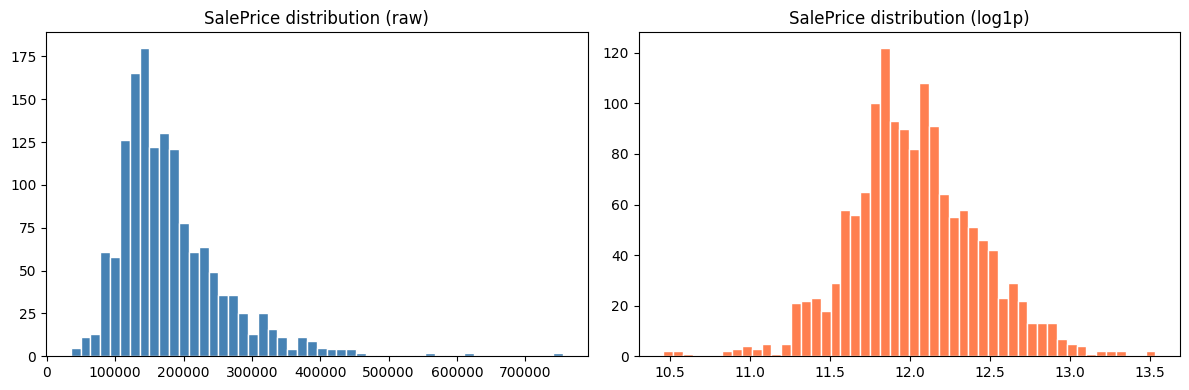

Top 10 columns with missing data:
PoolQC         0.995205
MiscFeature    0.963014
Alley          0.937671
Fence          0.807534
MasVnrType     0.597260
FireplaceQu    0.472603
LotFrontage    0.177397
GarageYrBlt    0.055479
GarageCond     0.055479
GarageType     0.055479
dtype: float64


In [34]:
# ── Quick EDA ──────────────────────────────────────────────────────────────
# Understand your data before building anything.

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_train['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice distribution (raw)')
axes[1].hist(np.log1p(df_train['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('SalePrice distribution (log1p)')
plt.tight_layout()
plt.show()

# Missing values
missing = df_train.isnull().mean().sort_values(ascending=False)
print('Top 10 columns with missing data:')
print(missing[missing > 0].head(10))

**Before moving on, answer these questions in a markdown cell:**
1. Is SalePrice normally distributed? Should you predict it directly or log-transform it first? Why?
2. How many features are numeric vs categorical?
3. How severe is the missing data problem? Does it affect many features or just a few?

1. SalePrice is not normally distributed,I should do a log-transform first
2. I think there would be 80 features(id is not a feature)
3. missing data is severe in some features like PoolQC, I think I would drop column with missing more than 0.2

---
## Section 2 — Preprocessing

### ✏️ TASK 2.1 — Implement `preprocess(df_train, df_test)`

**What this function does**: Takes the raw train and test DataFrames and returns numpy arrays ready for PyTorch.

**Arguments**:
- `df_train` (`pd.DataFrame`): raw training data, includes the `SalePrice` target column
- `df_test` (`pd.DataFrame`): raw test data, no target column

**Returns**: a dict with keys:
- `'X_train'` (`np.ndarray`, shape `[N_train, num_features]`, dtype `float32`)
- `'y_train'` (`np.ndarray`, shape `[N_train]`, dtype `float32`) — log1p of SalePrice
- `'X_test'`  (`np.ndarray`, shape `[N_test,  num_features]`, dtype `float32`)
- `'feature_names'` (`list[str]`): names of the final features, useful for debugging

**Algorithm** (implement each step):
```
1. Separate target: y = log1p(df_train['SalePrice'])
   Drop 'SalePrice' and 'Id' columns from df_train
   Drop 'Id' from df_test

2. Concatenate df_train and df_test along axis=0 for joint preprocessing
   (prevents data leakage from fitting scaler only on train)
   Keep track of the split index: split_idx = len(df_train)

3. Handle categorical columns:
   - Identify columns where dtype == 'object'
   - Fill NaN with the string 'Missing'
   - Apply pd.get_dummies() to one-hot encode them

4. Handle numeric columns:
   - Identify columns where dtype is numeric
   - Use sklearn SimpleImputer(strategy='median') to fill NaN
     IMPORTANT: fit the imputer on the full concatenated data

5. Standardize all numeric columns:
   - Use sklearn StandardScaler()
     IMPORTANT: fit the scaler on the full concatenated data

6. Split back into train and test using split_idx
   Convert everything to float32 numpy arrays
```

> **Why log1p the target?** SalePrice is right-skewed (you saw this in EDA). Predicting log-price makes the problem easier: errors become relative (predicting \$200k vs \$210k is penalized similarly to \$400k vs \$420k). This is standard practice for price prediction.

In [35]:
def preprocess(df_train, df_test):
    """
    Preprocess raw housing dataframes into model-ready numpy arrays.

    Returns a dict: {'X_train', 'y_train', 'X_test', 'feature_names'}
    """
    # YOUR CODE HERE
    y_train = np.log1p(df_train['SalePrice'].values).astype('float32')
    df_train = df_train.drop(columns=['Id','SalePrice'])
    df_test = df_test.drop(columns=['Id'])
    split_idx = len(df_train)
    df_total = pd.concat([df_train,df_test]).reset_index(drop=True)

    cat_col = df_total.select_dtypes(include='object').columns
    df_total[cat_col] = df_total[cat_col].fillna('Missing')
    df_total = pd.get_dummies(df_total,columns=cat_col)

    num_col = df_total.select_dtypes(include='number').columns
    imputer = SimpleImputer(strategy='median')
    df_total[num_col] = imputer.fit_transform(df_total[num_col])
    scaler = StandardScaler()
    df_total[num_col] = scaler.fit_transform(df_total[num_col])
    feature_names = df_total.columns
    X_train = df_total.iloc[:split_idx].values.astype('float32')
    X_test = df_total.iloc[split_idx:].values.astype('float32')
    return {
        'X_train':X_train,
        'y_train':y_train,
        'X_test':X_test,
        'feature_names':feature_names,
    }

In [36]:
# ── SANITY CHECK 2.1 ───────────────────────────────────────────────────────
data = preprocess(df_train.copy(), df_test.copy())

X_train = data['X_train']
y_train = data['y_train']
X_test  = data['X_test']

print(f'X_train shape : {X_train.shape}')   # expect (1460, ~300)
print(f'y_train shape : {y_train.shape}')   # expect (1460,)
print(f'X_test  shape : {X_test.shape}')    # expect (1459, same cols as X_train)
print(f'num features  : {len(data["feature_names"])}')
print(f'y_train range : [{y_train.min():.3f}, {y_train.max():.3f}]')  # expect ~[10.5, 13.5]
print(f'X_train dtype : {X_train.dtype}')   # expect float32

# Check: no NaN anywhere
assert not np.isnan(X_train).any(), 'X_train contains NaN!'
assert not np.isnan(y_train).any(), 'y_train contains NaN!'
assert X_train.shape[1] == X_test.shape[1], 'Train/test feature count mismatch!'

# Check: numeric columns are roughly standardized
col_means = X_train.mean(axis=0)
col_stds  = X_train.std(axis=0)
print(f'\nColumn mean  — min: {col_means.min():.3f}, max: {col_means.max():.3f}  (should be near 0)')
print(f'Column std   — min: {col_stds.min():.3f},  max: {col_stds.max():.3f}   (should be near 1 for numeric)')

print('\nAll sanity checks passed!')

X_train shape : (1460, 310)
y_train shape : (1460,)
X_test  shape : (1459, 310)
num features  : 310
y_train range : [10.460, 13.534]
X_train dtype : float32

Column mean  — min: -0.018, max: 0.999  (should be near 0)
Column std   — min: 0.000,  max: 1.265   (should be near 1 for numeric)

All sanity checks passed!


---
## Section 3 — PyTorch Dataset

### ✏️ TASK 3.1 — Implement `HousingDataset`

**What this class does**: Wraps the numpy arrays into a PyTorch Dataset so we can use DataLoader.

**Arguments to `__init__`**:
- `X` (`np.ndarray`, float32): feature matrix
- `y` (`np.ndarray`, float32, optional): targets. If `None`, this is a test set (no labels).

**Methods to implement**:
- `__len__`: returns number of samples
- `__getitem__(idx)`: returns a tuple `(x, y)` as PyTorch tensors. If `y` is None, return only `x`.

> **Tip**: Convert numpy arrays to tensors in `__init__`, not in `__getitem__`. Doing it once at construction is faster.

In [37]:
class HousingDataset(Dataset):
    """
    PyTorch Dataset for tabular housing data.

    Args:
        X (np.ndarray): features, shape [N, D], float32
        y (np.ndarray or None): targets, shape [N], float32
    """
    def __init__(self, X, y=None):
        # YOUR CODE HERE
        self.X = torch.tensor(X)
        if y is not None:
            self.y = torch.tensor(y)
            

    def __len__(self):
        # YOUR CODE HERE
        return len(self.X)

    def __getitem__(self, idx):
        # YOUR CODE HERE
        if self.y is not None:
            return self.X[idx],self.y[idx]
        return self.X[idx]

In [38]:
# ── SANITY CHECK 3.1 ───────────────────────────────────────────────────────
ds = HousingDataset(X_train, y_train)
x0, y0 = ds[0]

assert isinstance(x0, torch.Tensor), 'x should be a tensor'
assert isinstance(y0, torch.Tensor), 'y should be a tensor'
assert x0.shape == (X_train.shape[1],), f'Expected shape ({X_train.shape[1]},), got {x0.shape}'
assert y0.shape == (), f'y should be a scalar tensor, got shape {y0.shape}'
assert len(ds) == len(X_train), 'Dataset length mismatch'

# Test DataLoader works
loader = DataLoader(ds, batch_size=32, shuffle=True)
xb, yb = next(iter(loader))
assert xb.shape == (32, X_train.shape[1])
assert yb.shape == (32,)

print(f'Dataset size  : {len(ds)}')
print(f'Single item x : {x0.shape}, dtype={x0.dtype}')
print(f'Single item y : {y0.item():.4f}')
print(f'Batch x shape : {xb.shape}')
print('All sanity checks passed!')

Dataset size  : 1460
Single item x : torch.Size([310]), dtype=torch.float32
Single item y : 12.2477
Batch x shape : torch.Size([32, 310])
All sanity checks passed!


---
## Section 4 — The MLP

This is the core of the project. You will build an MLP that accepts **any** architecture configuration, so you can systematically vary it in your experiments.

### ✏️ TASK 4.1 — Implement `MLP`

**What this class does**: A fully-connected neural network with configurable depth, width, activation, and dropout.

**Arguments to `__init__`**:
- `input_dim` (`int`): number of input features (= `X_train.shape[1]`)
- `hidden_dims` (`list[int]`): list of hidden layer sizes. E.g. `[256, 128, 64]` means 3 hidden layers with those widths. An empty list `[]` means a linear model.
- `output_dim` (`int`): number of outputs. For regression: 1.
- `dropout` (`float`): dropout probability applied after each hidden layer. 0.0 = no dropout.
- `activation` (`str`): one of `'relu'`, `'gelu'`, `'tanh'`. Default `'relu'`.
- `use_batch_norm` (`bool`): whether to apply BatchNorm1d after each linear layer, before activation.

**Architecture diagram**:
```
Input (D)
  → Linear(D, hidden_dims[0])
  → [BatchNorm1d]  if use_batch_norm
  → Activation
  → Dropout(p)
  → Linear(hidden_dims[0], hidden_dims[1])
  → [BatchNorm1d]  if use_batch_norm
  → Activation
  → Dropout(p)
  → ...
  → Linear(hidden_dims[-1], output_dim)
  → (no activation on final layer — this is regression)
```

**Pseudocode**:
```python
def __init__(self, input_dim, hidden_dims, output_dim, dropout, activation, use_batch_norm):
    super().__init__()
    
    # 1. Choose activation function object based on the string argument
    #    Hint: use a dict mapping string → nn.ReLU(), nn.GELU(), nn.Tanh()
    
    # 2. Build a list of layers using a loop:
    #    in_features starts at input_dim
    #    for each size in hidden_dims:
    #        append nn.Linear(in_features, size)
    #        if use_batch_norm: append nn.BatchNorm1d(size)
    #        append activation
    #        if dropout > 0: append nn.Dropout(dropout)
    #        in_features = size  (update for next layer)
    
    # 3. After the loop, append the output layer:
    #    nn.Linear(in_features, output_dim)
    
    # 4. Wrap the list in nn.Sequential and store as self.net

def forward(self, x):
    # Pass x through self.net
    # Squeeze the output from shape [B, 1] to [B] for regression
    return self.net(x).squeeze(-1)
```

> **Design question**: Why is there no activation on the final output layer for regression?  
> Write your answer in the markdown cell below after you implement this.

In [39]:
class MLP(nn.Module):
    """
    Flexible multi-layer perceptron for tabular regression.

    Args:
        input_dim     (int):       number of input features
        hidden_dims   (list[int]): sizes of hidden layers, e.g. [256, 128]
        output_dim    (int):       number of output units (1 for regression)
        dropout       (float):     dropout probability after each hidden layer
        activation    (str):       'relu' | 'gelu' | 'tanh'
        use_batch_norm(bool):      apply BatchNorm1d before each activation
    """
    def __init__(
        self,
        input_dim,
        hidden_dims,
        output_dim=1,
        dropout=0.0,
        activation='relu',
        use_batch_norm=False
    ):
        super().__init__()
        # YOUR CODE HERE
        activation_dict={'relu':nn.ReLU(),'gelu':nn.GELU(),'tanh':nn.Tanh()}
        layers = []
        if len(hidden_dims) == 0:
            layers.append(nn.Linear(input_dim,output_dim))
        else:
            layers.append(nn.Linear(input_dim,hidden_dims[0]))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dims[0]))
            layers.append(activation_dict[activation])
            layers.append(nn.Dropout(dropout))
            for i in range(len(hidden_dims)):
                if i < len(hidden_dims)-1:
                    layers.append(nn.Linear(hidden_dims[i],hidden_dims[i+1]))
                    if use_batch_norm:
                        layers.append(nn.BatchNorm1d(hidden_dims[i+1]))
                    layers.append(activation_dict[activation])
                    layers.append(nn.Dropout(dropout))
                else:
                    layers.append(nn.Linear(hidden_dims[-1],output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        # YOUR CODE HERE
        return self.model(x).squeeze(1)

In [40]:
# ── SANITY CHECK 4.1 ───────────────────────────────────────────────────────
INPUT_DIM = X_train.shape[1]

# Test 1: basic forward pass
model = MLP(input_dim=INPUT_DIM, hidden_dims=[128, 64], output_dim=1, dropout=0.1)
dummy = torch.randn(32, INPUT_DIM)
out   = model(dummy)
assert out.shape == (32,), f'Expected (32,), got {out.shape}'
print(f'Output shape: {out.shape}  ✓')

# Test 2: single hidden layer
model_shallow = MLP(INPUT_DIM, hidden_dims=[256], output_dim=1)
out2 = model_shallow(dummy)
assert out2.shape == (32,)
print(f'Shallow model output: {out2.shape}  ✓')

# Test 3: linear model (no hidden layers)
model_linear = MLP(INPUT_DIM, hidden_dims=[], output_dim=1)
out3 = model_linear(dummy)
assert out3.shape == (32,)
print(f'Linear model output:  {out3.shape}  ✓')

# Test 4: batch norm variant
model_bn = MLP(INPUT_DIM, hidden_dims=[128, 64], output_dim=1, use_batch_norm=True)
model_bn.train()
out4 = model_bn(dummy)
assert out4.shape == (32,)
print(f'BatchNorm model output: {out4.shape}  ✓')

# Count parameters — should scale roughly with hidden dims
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

p1 = count_params(MLP(INPUT_DIM, [64]))
p2 = count_params(MLP(INPUT_DIM, [256]))
assert p2 > p1, 'Wider model should have more parameters'
print(f'\nParam count [64]:  {p1:,}')
print(f'Param count [256]: {p2:,}  (should be larger)  ✓')
print('\nAll sanity checks passed!')

Output shape: torch.Size([32])  ✓
Shallow model output: torch.Size([32])  ✓
Linear model output:  torch.Size([32])  ✓
BatchNorm model output: torch.Size([32])  ✓

Param count [64]:  19,969
Param count [256]: 79,873  (should be larger)  ✓

All sanity checks passed!


**Answer: why no activation on the final layer?**

Because this is a regression problem, the output is unbounded

---
## Section 5 — Training loop

### ✏️ TASK 5.1 — Implement `train_one_epoch`

**What this function does**: Runs one full pass over the training DataLoader, updating weights.

**Arguments**:
- `model` (`nn.Module`): the MLP being trained
- `loader` (`DataLoader`): training data loader
- `optimizer` (`torch.optim.Optimizer`): e.g. Adam
- `criterion` (`nn.Module`): loss function, e.g. `nn.MSELoss()`
- `device` (`torch.device`): where to run

**Returns**: `float` — average training loss across all batches

**Pseudocode**:
```
set model to train mode
total_loss = 0.0

for each (x_batch, y_batch) in loader:
    move x_batch, y_batch to device
    zero the optimizer gradients
    predictions = model(x_batch)           # forward pass
    loss = criterion(predictions, y_batch) # compute loss
    loss.backward()                        # backprop
    optimizer.step()                       # update weights
    total_loss += loss.item()

return total_loss / len(loader)  # average over batches
```

In [41]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Train model for one epoch.

    Returns:
        float: mean training loss over all batches
    """
    # YOUR CODE HERE
    model.train()
    total_loss = 0.0
    for X_batch,y_batch in loader:
        X_batch,y_batch = X_batch.to(device),y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds,y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss/len(loader)

### ✏️ TASK 5.2 — Implement `evaluate`

**What this function does**: Computes validation loss (no gradient updates) and returns the RMSE on the original price scale (not log scale).

**Arguments**: same as `train_one_epoch` but no optimizer

**Returns**: tuple `(val_loss_mse: float, val_rmsle: float)`
- `val_loss_mse`: mean MSE loss on log-price (matches training loss scale)
- `val_rmsle`: Root Mean Squared Log Error — the Kaggle competition metric:
  `RMSLE = sqrt( mean( (log1p(y_pred_price) - log1p(y_true_price))^2 ) )`
  Since your targets are already log1p-transformed, this simplifies to `sqrt(MSE)` on your stored targets.

**Pseudocode**:
```
set model to eval mode
all_preds = []
all_targets = []

with torch.no_grad():   # important! disables gradient computation
    for each (x_batch, y_batch) in loader:
        move to device
        preds = model(x_batch)
        collect preds and targets

concatenate all predictions and targets
mse = mean( (preds - targets)^2 )
rmsle = sqrt(mse)       # because targets are already log1p
return mse, rmsle
```

In [42]:
def evaluate(model, loader, criterion, device):
    """
    Evaluate model on a validation DataLoader.

    Returns:
        (val_mse, val_rmsle): both floats
    """
    # YOUR CODE HERE
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X_batch,y_batch in loader:
            X_batch,y_batch = X_batch.to(device),y_batch.to(device)
            preds = model(X_batch)
            all_preds.append(preds)
            all_targets.append(y_batch)
    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    val_mse = torch.mean((all_preds-all_targets)**2)
    val_rmsle = torch.sqrt(val_mse)
    return val_mse.item(), val_rmsle.item()

### ✏️ TASK 5.3 — Implement `train_model`

**What this function does**: Full training loop with validation, early stopping, and W&B logging.

**Arguments**:
- `config` (`dict`): all hyperparameters in one place (see spec below)
- `X_train`, `y_train` (`np.ndarray`): full training data
- `device` (`torch.device`)
- `use_wandb` (`bool`): whether to log to Weights & Biases

**`config` dict keys**:
```python
config = {
    'hidden_dims'    : [256, 128],   # list of layer widths
    'dropout'        : 0.2,          # dropout probability
    'activation'     : 'relu',       # 'relu' | 'gelu' | 'tanh'
    'use_batch_norm' : False,
    'lr'             : 1e-3,         # Adam learning rate
    'weight_decay'   : 1e-4,         # L2 regularization
    'batch_size'     : 64,
    'epochs'         : 100,
    'val_fraction'   : 0.15,         # fraction of train data for validation
    'patience'       : 15,           # early stopping patience
}
```

**Returns**: `dict` with keys:
- `'model'`: the best model (lowest val loss)
- `'train_losses'`: list of per-epoch train losses
- `'val_losses'`: list of per-epoch val RMSLE values
- `'best_val_rmsle'`: float, the best validation RMSLE achieved
- `'config'`: the config dict (for logging)

**Algorithm**:
```
1. Split X_train/y_train into train and val splits (use train_test_split)

2. Create HousingDataset and DataLoader for each split

3. Instantiate MLP using config

4. Instantiate Adam optimizer with config['lr'] and config['weight_decay']

5. Instantiate nn.MSELoss()

6. Training loop for config['epochs'] epochs:
   a. train_one_epoch → get train_loss
   b. evaluate on val loader → get val_mse, val_rmsle
   c. if use_wandb: log {'train_loss': train_loss, 'val_rmsle': val_rmsle, 'epoch': epoch}
   d. Early stopping:
      - if val_rmsle < best_val_rmsle:
            best_val_rmsle = val_rmsle
            save a copy of model state (use copy.deepcopy)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config['patience']: break

7. Restore best model weights

8. Return results dict
```

> **Why early stopping?** Neural networks eventually overfit. Instead of picking epochs by hand, we watch validation loss. If it hasn't improved in `patience` epochs, training has stalled — stop and restore the best checkpoint.

In [43]:
import copy

def train_model(config, X_train, y_train, device, use_wandb=False):
    """
    Full training run with early stopping and optional W&B logging.

    Returns:
        dict: {'model', 'train_losses', 'val_losses', 'best_val_rmsle', 'config'}
    """
    # YOUR CODE HERE
    split_idx = int(len(X_train)*config['val_fraction'])
    indices = np.random.permutation(len(X_train))
    X_train = X_train[indices]
    y_train = y_train[indices]
    X_val = X_train[:split_idx]
    y_val = y_train[:split_idx]
    X_train = X_train[split_idx:]
    y_train = y_train[split_idx:]
    model = MLP(input_dim=X_train.shape[1], hidden_dims=config['hidden_dims'], output_dim=1, 
                dropout=config['dropout'],activation=config['activation'],use_batch_norm=config['use_batch_norm']).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(),lr=config['lr'],weight_decay=config['weight_decay'])
    train_dataset = HousingDataset(X_train,y_train)
    train_loader = DataLoader(train_dataset,batch_size=config['batch_size'],shuffle=True)
    val_dataset = HousingDataset(X_val,y_val)
    val_loader = DataLoader(val_dataset,batch_size=config['batch_size'],shuffle=False)
    best_val_rmsle = float('inf')
    patience_counter = 0
    train_losses = []
    val_losses = []
    for epoch in range(config['epochs']):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)
        val_mse,val_rmsle = evaluate(model,val_loader,criterion,device)
        val_losses.append(val_mse)
        print(f"epoch{epoch+1}, train_loss: {train_loss:.4f}, val_mse: {val_mse:.4f},val_rmsle: {val_rmsle:.4f}")
        if use_wandb:
            wandb.log({'train_loss':train_loss,'val_mse':val_mse,'val_rmsle':val_rmsle,'epoch':epoch})
        if val_rmsle < best_val_rmsle:
            best_val_rmsle=val_rmsle
            patience_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
            print(f"new best val rmsle {best_val_rmsle:.4f}, model saved")
        else:
            patience_counter += 1
        if patience_counter >= config['patience']:
            break
    model.load_state_dict(best_model_weights)
    return {'model':model,'train_losses':train_losses,'val_losses':val_losses, 'best_val_rmsle':best_val_rmsle, 'config':config}
        

epoch1, train_loss: 124.0409, val_mse: 95.4040,val_rmsle: 9.7675
new best val rmsle 9.7675, model saved
epoch2, train_loss: 52.3252, val_mse: 6.3945,val_rmsle: 2.5287
new best val rmsle 2.5287, model saved
epoch3, train_loss: 4.3213, val_mse: 0.9101,val_rmsle: 0.9540
new best val rmsle 0.9540, model saved
epoch4, train_loss: 2.1359, val_mse: 0.4547,val_rmsle: 0.6743
new best val rmsle 0.6743, model saved
epoch5, train_loss: 1.7085, val_mse: 0.0516,val_rmsle: 0.2271
new best val rmsle 0.2271, model saved
epoch6, train_loss: 1.6655, val_mse: 0.0602,val_rmsle: 0.2453
epoch7, train_loss: 1.5866, val_mse: 0.0907,val_rmsle: 0.3012
epoch8, train_loss: 1.6444, val_mse: 0.0380,val_rmsle: 0.1950
new best val rmsle 0.1950, model saved
epoch9, train_loss: 1.6209, val_mse: 0.0360,val_rmsle: 0.1897
new best val rmsle 0.1897, model saved
epoch10, train_loss: 1.5305, val_mse: 0.0384,val_rmsle: 0.1959
epoch11, train_loss: 1.5318, val_mse: 0.0386,val_rmsle: 0.1964
epoch12, train_loss: 1.6776, val_mse: 0

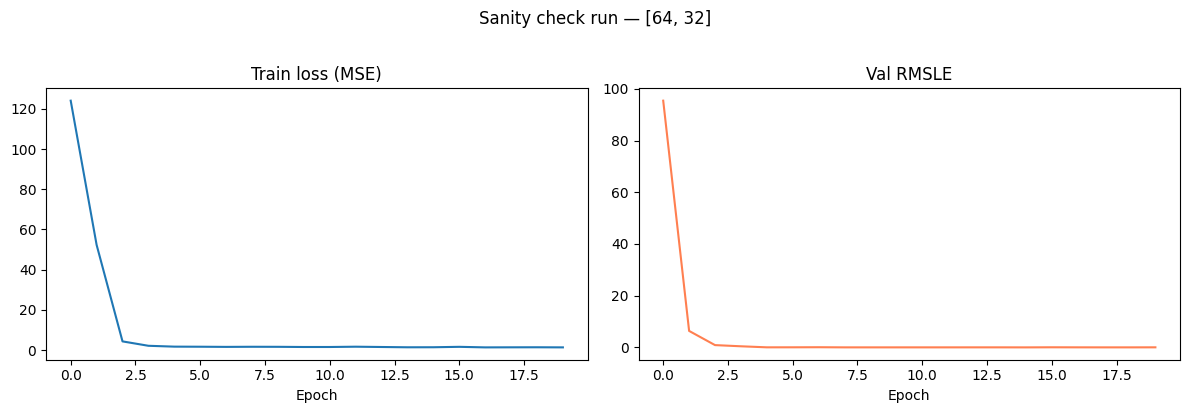

In [44]:
# ── SANITY CHECK 5.1–5.3 ──────────────────────────────────────────────────
# Run a quick training job to verify your entire pipeline works.
# This uses a tiny config so it's fast — real experiments come in Section 6.

test_config = {
    'hidden_dims'    : [64, 32],
    'dropout'        : 0.1,
    'activation'     : 'relu',
    'use_batch_norm' : False,
    'lr'             : 1e-3,
    'weight_decay'   : 1e-4,
    'batch_size'     : 64,
    'epochs'         : 20,          # short for sanity check
    'val_fraction'   : 0.15,
    'patience'       : 20,
}

result = train_model(test_config, X_train, y_train, DEVICE, use_wandb=False)

assert 'model'          in result
assert 'train_losses'   in result
assert 'val_losses'     in result
assert 'best_val_rmsle' in result
assert len(result['train_losses']) <= 20
assert result['best_val_rmsle'] > 0

# Loss should decrease over training
first_loss = result['train_losses'][0]
last_loss  = result['train_losses'][-1]
print(f'Train loss — first epoch: {first_loss:.4f}, last epoch: {last_loss:.4f}')
assert last_loss < first_loss, 'Training loss did not decrease — check your training loop!'

print(f'Best val RMSLE: {result["best_val_rmsle"]:.4f}')
print(f'Stopped after {len(result["train_losses"])} epochs')
print('All sanity checks passed!')

# Plot the learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(result['train_losses'])
axes[0].set_title('Train loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[1].plot(result['val_losses'], color='coral')
axes[1].set_title('Val RMSLE')
axes[1].set_xlabel('Epoch')
plt.suptitle('Sanity check run — [64, 32]', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 6 — Ablation experiments

This is the heart of the project. You will run **four systematic experiments**, each varying exactly one thing while holding everything else constant. This is called an **ablation study** — isolating the effect of each design choice.

Before running each experiment, write a **hypothesis** in the markdown cell. After, write your **observation and explanation**.

### ✏️ TASK 6.1 — Implement `run_ablation`

**What this function does**: Takes a base config and a dict of values to sweep over one hyperparameter, runs `train_model` for each, and returns results in a tidy DataFrame.

**Arguments**:
- `base_config` (`dict`): default config, as defined above
- `sweep_key` (`str`): which config key to vary, e.g. `'hidden_dims'`
- `sweep_values` (`list`): list of values to try for that key
- `X_train`, `y_train`: training data
- `device`
- `use_wandb` (`bool`)

**Returns**: `pd.DataFrame` with columns:
- `sweep_value` (str): the value that was tested (convert to string for display)
- `best_val_rmsle` (float)
- `num_epochs` (int): how many epochs it ran before stopping
- `num_params` (int): parameter count of the model

**Pseudocode**:
```
rows = []
for value in sweep_values:
    config = copy of base_config
    config[sweep_key] = value

    if use_wandb:
        init a wandb run with name=f'{sweep_key}={value}', config=config

    result = train_model(config, X_train, y_train, device, use_wandb)
    num_params = count_params(result['model'])

    if use_wandb: wandb.finish()

    rows.append({
        'sweep_value'   : str(value),
        'best_val_rmsle': result['best_val_rmsle'],
        'num_epochs'    : len(result['train_losses']),
        'num_params'    : num_params,
    })
return pd.DataFrame(rows)
```

In [45]:
def count_params(model):
    """Count trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def run_ablation(base_config, sweep_key, sweep_values, X_train, y_train, device, use_wandb=False):
    """
    Run one ablation — vary sweep_key across sweep_values.

    Returns:
        pd.DataFrame with columns: sweep_value, best_val_rmsle, num_epochs, num_params
    """
    # YOUR CODE HERE
    rows= []
    for value in sweep_values:
        config = copy.copy(base_config)
        config[sweep_key] = value
        if use_wandb:
            wandb.init(
                project='house-price-mlp',
                name = f"{sweep_key} = {value}",
                config = config
            )
        result = train_model(config,X_train,y_train,device,use_wandb)
        num_params = count_params(result['model'])
        if use_wandb:
            wandb.finish()
        rows.append({
            'sweep_value':str(value),
            'best_val_rmsle':result['best_val_rmsle'],
            'num_epochs':len(result['train_losses']),
            'num_params':num_params
        })
    return pd.DataFrame(rows)

In [46]:
# ── SANITY CHECK 6.1 ───────────────────────────────────────────────────────
# Tiny sweep over dropout to verify run_ablation works before the real runs.

base_config = {
    'hidden_dims'    : [128, 64],
    'dropout'        : 0.2,
    'activation'     : 'relu',
    'use_batch_norm' : False,
    'lr'             : 1e-3,
    'weight_decay'   : 1e-4,
    'batch_size'     : 64,
    'epochs'         : 30,
    'val_fraction'   : 0.15,
    'patience'       : 15,
}

check_df = run_ablation(base_config, 'dropout', [0.0, 0.3], X_train, y_train, DEVICE)
assert isinstance(check_df, pd.DataFrame)
assert list(check_df.columns) == ['sweep_value', 'best_val_rmsle', 'num_epochs', 'num_params']
assert len(check_df) == 2
print(check_df)
print('Sanity check passed!')

epoch1, train_loss: 118.8885, val_mse: 64.2583,val_rmsle: 8.0161
new best val rmsle 8.0161, model saved
epoch2, train_loss: 17.9691, val_mse: 7.5749,val_rmsle: 2.7523
new best val rmsle 2.7523, model saved
epoch3, train_loss: 1.8524, val_mse: 0.7916,val_rmsle: 0.8897
new best val rmsle 0.8897, model saved
epoch4, train_loss: 0.2902, val_mse: 0.0650,val_rmsle: 0.2549
new best val rmsle 0.2549, model saved
epoch5, train_loss: 0.0853, val_mse: 0.0440,val_rmsle: 0.2097
new best val rmsle 0.2097, model saved
epoch6, train_loss: 0.0529, val_mse: 0.0342,val_rmsle: 0.1850
new best val rmsle 0.1850, model saved
epoch7, train_loss: 0.0418, val_mse: 0.0264,val_rmsle: 0.1625
new best val rmsle 0.1625, model saved
epoch8, train_loss: 0.0349, val_mse: 0.0233,val_rmsle: 0.1528
new best val rmsle 0.1528, model saved
epoch9, train_loss: 0.0299, val_mse: 0.0208,val_rmsle: 0.1444
new best val rmsle 0.1444, model saved
epoch10, train_loss: 0.0272, val_mse: 0.0192,val_rmsle: 0.1385
new best val rmsle 0.138

---
### Experiment 1 — Effect of depth

**Question**: How does the number of layers affect performance and training behavior?

**Hypothesis** *(write before running)*: 
I guess deep models will work better, but with the tradeoff of computing cost

*(What do you expect will happen as you add more layers? At what point do you think performance will stop improving or start degrading? Why?)*

In [47]:
# W&B login (optional but strongly encouraged — free account at wandb.ai)
# wandb.login()
USE_WANDB = False  # set True once your wandb account is set up

depth_configs = [
    [],                     # linear model — no hidden layers
    [128],                  # 1 hidden layer
    [128, 128],             # 2 hidden layers
    [128, 128, 128],        # 3 hidden layers
    [128, 128, 128, 128],   # 4 hidden layers
]

depth_base = {**base_config, 'epochs': 150, 'patience': 20}

depth_results = run_ablation(
    depth_base, 'hidden_dims', depth_configs,
    X_train, y_train, DEVICE, use_wandb=USE_WANDB
)
depth_results['num_layers'] = depth_results['sweep_value'].apply(
    lambda s: len(eval(s)) if s != '[]' else 0
)
print(depth_results.sort_values('num_layers'))

epoch1, train_loss: 134.1802, val_mse: 124.8556,val_rmsle: 11.1739
new best val rmsle 11.1739, model saved
epoch2, train_loss: 115.2170, val_mse: 106.7591,val_rmsle: 10.3324
new best val rmsle 10.3324, model saved
epoch3, train_loss: 98.1081, val_mse: 90.6461,val_rmsle: 9.5208
new best val rmsle 9.5208, model saved
epoch4, train_loss: 83.0317, val_mse: 76.4851,val_rmsle: 8.7456
new best val rmsle 8.7456, model saved
epoch5, train_loss: 69.8696, val_mse: 64.0976,val_rmsle: 8.0061
new best val rmsle 8.0061, model saved
epoch6, train_loss: 58.2748, val_mse: 53.3362,val_rmsle: 7.3032
new best val rmsle 7.3032, model saved
epoch7, train_loss: 48.3056, val_mse: 44.1057,val_rmsle: 6.6412
new best val rmsle 6.6412, model saved
epoch8, train_loss: 39.7265, val_mse: 36.1951,val_rmsle: 6.0162
new best val rmsle 6.0162, model saved
epoch9, train_loss: 32.4798, val_mse: 29.4675,val_rmsle: 5.4284
new best val rmsle 5.4284, model saved
epoch10, train_loss: 26.2978, val_mse: 23.8198,val_rmsle: 4.8805


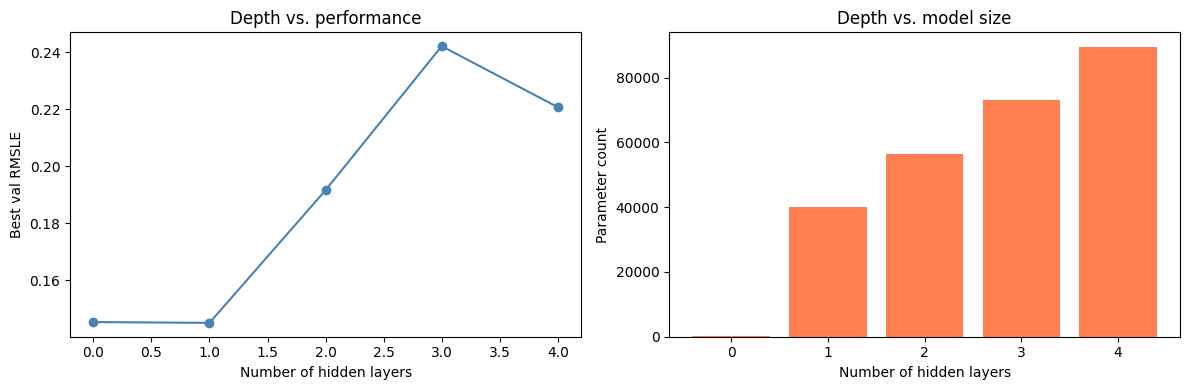

In [48]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

d = depth_results.sort_values('num_layers')
axes[0].plot(d['num_layers'], d['best_val_rmsle'], marker='o', color='steelblue')
axes[0].set_xlabel('Number of hidden layers')
axes[0].set_ylabel('Best val RMSLE')
axes[0].set_title('Depth vs. performance')

axes[1].bar(d['num_layers'].astype(str), d['num_params'], color='coral')
axes[1].set_xlabel('Number of hidden layers')
axes[1].set_ylabel('Parameter count')
axes[1].set_title('Depth vs. model size')

plt.tight_layout()
plt.show()

**Observation and explanation** *(write after running)*:

1. At what depth did performance peak?
2. Did very deep models perform worse? If so, why might that be on a dataset of only 1460 samples?
3. Was your hypothesis correct?

*(Your answers here)*

at the zero depth the model works best.

yes, very deep model works worst, I think it may be overfitting.

my hypothesis is not correct.

---
### Experiment 2 — Effect of width

**Question**: For a fixed depth, what is the right hidden dimension?

**Hypothesis** *(write before running)*:

*(How do you expect wider networks to behave? Is more capacity always better? What might limit it?)*

In [49]:
# Fix depth at 2 layers, vary width
width_configs = [
    [32, 32],
    [64, 64],
    [128, 128],
    [256, 256],
    [512, 512],
    [1024, 1024],
]

width_base = {**base_config, 'epochs': 150, 'patience': 20}

width_results = run_ablation(
    width_base, 'hidden_dims', width_configs,
    X_train, y_train, DEVICE, use_wandb=USE_WANDB
)
width_results['width'] = width_results['sweep_value'].apply(lambda s: eval(s)[0])
print(width_results.sort_values('width'))

epoch1, train_loss: 131.6846, val_mse: 117.0758,val_rmsle: 10.8202
new best val rmsle 10.8202, model saved
epoch2, train_loss: 91.3796, val_mse: 55.2943,val_rmsle: 7.4360
new best val rmsle 7.4360, model saved
epoch3, train_loss: 24.4883, val_mse: 0.4693,val_rmsle: 0.6851
new best val rmsle 0.6851, model saved
epoch4, train_loss: 5.6344, val_mse: 0.1021,val_rmsle: 0.3196
new best val rmsle 0.3196, model saved
epoch5, train_loss: 4.5418, val_mse: 0.5642,val_rmsle: 0.7512
epoch6, train_loss: 4.6761, val_mse: 0.1731,val_rmsle: 0.4160
epoch7, train_loss: 4.4911, val_mse: 0.1469,val_rmsle: 0.3833
epoch8, train_loss: 4.7200, val_mse: 0.2117,val_rmsle: 0.4601
epoch9, train_loss: 4.5460, val_mse: 0.1001,val_rmsle: 0.3163
new best val rmsle 0.3163, model saved
epoch10, train_loss: 4.3998, val_mse: 0.0875,val_rmsle: 0.2959
new best val rmsle 0.2959, model saved
epoch11, train_loss: 4.3291, val_mse: 0.3475,val_rmsle: 0.5895
epoch12, train_loss: 4.3012, val_mse: 0.2475,val_rmsle: 0.4974
epoch13, t

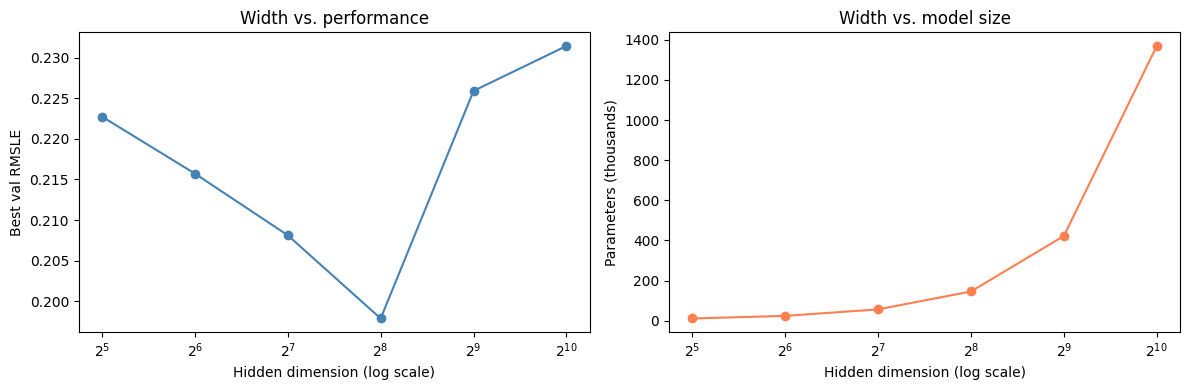

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

w = width_results.sort_values('width')
axes[0].semilogx(w['width'], w['best_val_rmsle'], marker='o', color='steelblue', base=2)
axes[0].set_xlabel('Hidden dimension (log scale)')
axes[0].set_ylabel('Best val RMSLE')
axes[0].set_title('Width vs. performance')

axes[1].semilogx(w['width'], w['num_params'] / 1e3, marker='o', color='coral', base=2)
axes[1].set_xlabel('Hidden dimension (log scale)')
axes[1].set_ylabel('Parameters (thousands)')
axes[1].set_title('Width vs. model size')

plt.tight_layout()
plt.show()

**Observation and explanation**:

1. At what width did you hit diminishing returns?
2. Did the very wide model (1024) overfit? How can you tell from RMSLE alone?
3. The dataset has ~300 features and 1460 samples. Does this ratio affect how wide your model should be?

*(Your answers here)*

---
### Experiment 3 — Effect of dropout

**Question**: How does dropout interact with model capacity?

**Hypothesis** *(write before running)*:

*(Do you expect dropout to help more with large or small models? What range of dropout seems reasonable?)*

In [51]:
# Fix architecture at a wide model that you saw likely overfits, sweep dropout
dropout_base = {**base_config, 'hidden_dims': [512, 512], 'epochs': 150, 'patience': 20}

dropout_results = run_ablation(
    dropout_base, 'dropout', [0.0, 0.1, 0.2, 0.3, 0.5, 0.7],
    X_train, y_train, DEVICE, use_wandb=USE_WANDB
)
dropout_results['dropout'] = dropout_results['sweep_value'].astype(float)
print(dropout_results.sort_values('dropout'))

epoch1, train_loss: 44.8888, val_mse: 4.6111,val_rmsle: 2.1473
new best val rmsle 2.1473, model saved
epoch2, train_loss: 3.2859, val_mse: 0.4387,val_rmsle: 0.6623
new best val rmsle 0.6623, model saved
epoch3, train_loss: 0.4703, val_mse: 0.3312,val_rmsle: 0.5755
new best val rmsle 0.5755, model saved
epoch4, train_loss: 0.1307, val_mse: 0.2869,val_rmsle: 0.5357
new best val rmsle 0.5357, model saved
epoch5, train_loss: 0.0738, val_mse: 0.2230,val_rmsle: 0.4722
new best val rmsle 0.4722, model saved
epoch6, train_loss: 0.0547, val_mse: 0.1930,val_rmsle: 0.4393
new best val rmsle 0.4393, model saved
epoch7, train_loss: 0.0417, val_mse: 0.1817,val_rmsle: 0.4262
new best val rmsle 0.4262, model saved
epoch8, train_loss: 0.0346, val_mse: 0.1676,val_rmsle: 0.4094
new best val rmsle 0.4094, model saved
epoch9, train_loss: 0.0289, val_mse: 0.1671,val_rmsle: 0.4088
new best val rmsle 0.4088, model saved
epoch10, train_loss: 0.0244, val_mse: 0.1513,val_rmsle: 0.3890
new best val rmsle 0.3890, 

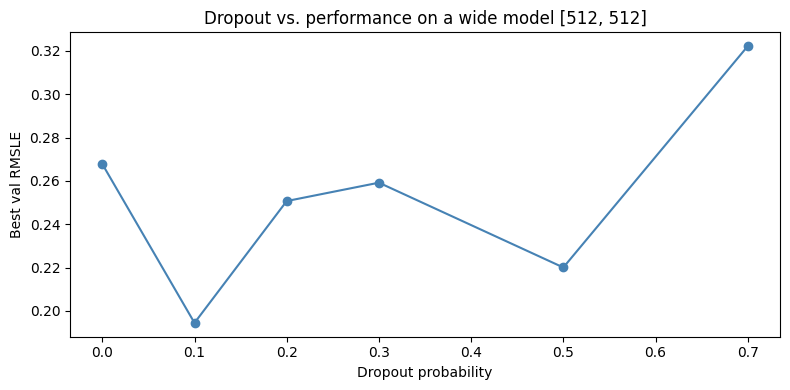

In [52]:
fig, ax = plt.subplots(figsize=(8, 4))
d = dropout_results.sort_values('dropout')
ax.plot(d['dropout'], d['best_val_rmsle'], marker='o', color='steelblue')
ax.set_xlabel('Dropout probability')
ax.set_ylabel('Best val RMSLE')
ax.set_title('Dropout vs. performance on a wide model [512, 512]')
plt.tight_layout()
plt.show()

**Observation and explanation**:

1. Was dropout helpful? At what value?
2. What happened at dropout=0.7? Why?
3. How does the optimal dropout for [512, 512] compare to what you'd expect for [64, 64]?

*(Your answers here)*

---
### Experiment 4 — Effect of learning rate

**Question**: How sensitive is training to learning rate?

**Hypothesis** *(write before running)*:

*(What do you expect to see at very high vs very low learning rates? What is a good starting point for Adam?)*

In [53]:
lr_base = {**base_config, 'hidden_dims': [256, 128], 'epochs': 150, 'patience': 20}

lr_results = run_ablation(
    lr_base, 'lr', [1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2],
    X_train, y_train, DEVICE, use_wandb=USE_WANDB
)
lr_results['lr'] = lr_results['sweep_value'].astype(float)
print(lr_results.sort_values('lr'))

epoch1, train_loss: 145.3425, val_mse: 144.8329,val_rmsle: 12.0347
new best val rmsle 12.0347, model saved
epoch2, train_loss: 144.4694, val_mse: 144.1943,val_rmsle: 12.0081
new best val rmsle 12.0081, model saved
epoch3, train_loss: 143.9080, val_mse: 143.5487,val_rmsle: 11.9812
new best val rmsle 11.9812, model saved
epoch4, train_loss: 143.4039, val_mse: 142.8824,val_rmsle: 11.9533
new best val rmsle 11.9533, model saved
epoch5, train_loss: 142.5440, val_mse: 142.1848,val_rmsle: 11.9241
new best val rmsle 11.9241, model saved
epoch6, train_loss: 141.9053, val_mse: 141.4521,val_rmsle: 11.8934
new best val rmsle 11.8934, model saved
epoch7, train_loss: 141.2181, val_mse: 140.6713,val_rmsle: 11.8605
new best val rmsle 11.8605, model saved
epoch8, train_loss: 140.2829, val_mse: 139.8292,val_rmsle: 11.8249
new best val rmsle 11.8249, model saved
epoch9, train_loss: 139.5273, val_mse: 138.9156,val_rmsle: 11.7862
new best val rmsle 11.7862, model saved
epoch10, train_loss: 138.5708, val_ms

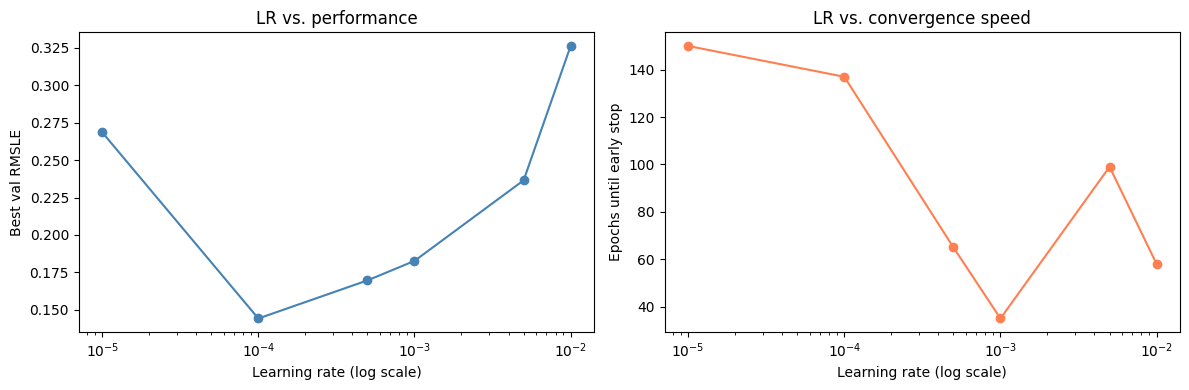

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

d = lr_results.sort_values('lr')
axes[0].semilogx(d['lr'], d['best_val_rmsle'], marker='o', color='steelblue')
axes[0].set_xlabel('Learning rate (log scale)')
axes[0].set_ylabel('Best val RMSLE')
axes[0].set_title('LR vs. performance')

axes[1].semilogx(d['lr'], d['num_epochs'], marker='o', color='coral')
axes[1].set_xlabel('Learning rate (log scale)')
axes[1].set_ylabel('Epochs until early stop')
axes[1].set_title('LR vs. convergence speed')

plt.tight_layout()
plt.show()

**Observation and explanation**:

1. What happened at very high LR (1e-2)? Did it converge?
2. What happened at very low LR (1e-5)? How many epochs did it run?
3. Where is the sweet spot? Does this match the common advice to start Adam at 1e-3?

*(Your answers here)*

---
## Section 7 — Best model and final summary

### ✏️ TASK 7.1 — Design your best model

Using everything you learned from the four ablations, design your best config by hand. Do not grid search — reason through each choice and justify it in the markdown cell.

Fill in the config below, then run it.

In [55]:
# Fill in your best config based on the ablation results
best_config = {
    'hidden_dims'    : [],       # YOUR CHOICE — justify below
    'dropout'        : 0.0,      # YOUR CHOICE
    'activation'     : 'relu',   # try 'gelu' too — any difference?
    'use_batch_norm' : False,     # YOUR CHOICE
    'lr'             : 1e-3,     # YOUR CHOICE
    'weight_decay'   : 1e-4,
    'batch_size'     : 64,
    'epochs'         : 300,
    'val_fraction'   : 0.15,
    'patience'       : 25,
}

best_result = train_model(best_config, X_train, y_train, DEVICE, use_wandb=USE_WANDB)
print(f'Best val RMSLE: {best_result["best_val_rmsle"]:.4f}')
print(f'Trained for {len(best_result["train_losses"])} epochs')
print(f'Model parameters: {count_params(best_result["model"]):,}')

epoch1, train_loss: 132.1187, val_mse: 120.8406,val_rmsle: 10.9928
new best val rmsle 10.9928, model saved
epoch2, train_loss: 113.1124, val_mse: 103.1954,val_rmsle: 10.1585
new best val rmsle 10.1585, model saved
epoch3, train_loss: 96.2605, val_mse: 87.5241,val_rmsle: 9.3554
new best val rmsle 9.3554, model saved
epoch4, train_loss: 81.3434, val_mse: 73.7518,val_rmsle: 8.5879
new best val rmsle 8.5879, model saved
epoch5, train_loss: 68.2394, val_mse: 61.7208,val_rmsle: 7.8563
new best val rmsle 7.8563, model saved
epoch6, train_loss: 56.8416, val_mse: 51.2797,val_rmsle: 7.1610
new best val rmsle 7.1610, model saved
epoch7, train_loss: 47.0910, val_mse: 42.2855,val_rmsle: 6.5027
new best val rmsle 6.5027, model saved
epoch8, train_loss: 38.5908, val_mse: 34.6010,val_rmsle: 5.8823
new best val rmsle 5.8823, model saved
epoch9, train_loss: 31.5103, val_mse: 28.1092,val_rmsle: 5.3018
new best val rmsle 5.3018, model saved
epoch10, train_loss: 25.4578, val_mse: 22.6363,val_rmsle: 4.7578


**Justify every choice in your best config**:

- hidden_dims: *why these specific values?*
- dropout: *why this value?*
- lr: *why this value?*
- use_batch_norm: *did you try it? did it help or hurt?*

*(Your answers here)*

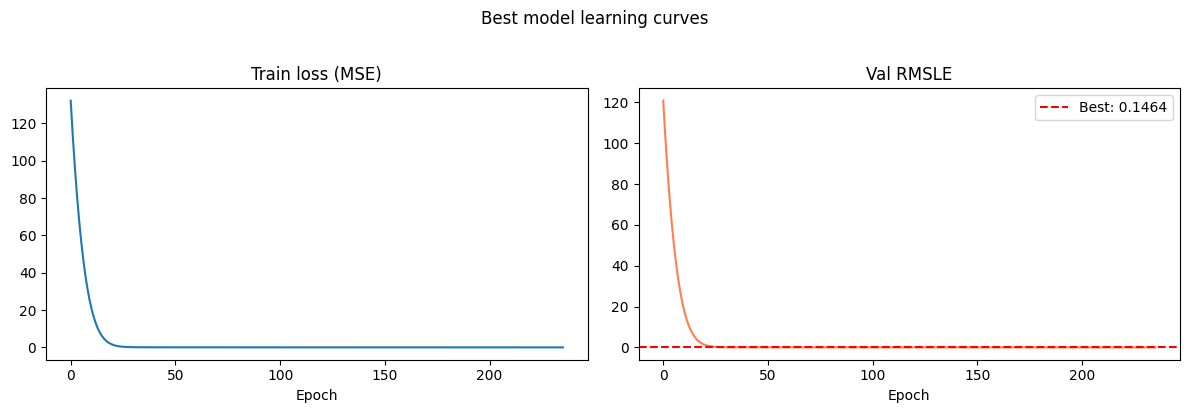

In [56]:
# Final learning curve for your best model
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(best_result['train_losses'])
axes[0].set_title('Train loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[1].plot(best_result['val_losses'], color='coral')
axes[1].axhline(y=best_result['best_val_rmsle'], color='red', linestyle='--', label=f'Best: {best_result["best_val_rmsle"]:.4f}')
axes[1].set_title('Val RMSLE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.suptitle('Best model learning curves', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 8 — Reflection questions

Answer all of these before considering this project complete. These are the questions an interviewer might ask you.

1. **Underfitting vs overfitting**: In your experiments, what did each look like concretely? What did the val loss curve look like when overfitting? When underfitting?

2. **Depth vs width**: For this dataset, which mattered more? Is that what you expected? Hint: think about what depth adds (composability of features) vs what width adds (more features per layer).

3. **Inductive bias**: MLPs have no inductive bias for this tabular data — every feature is treated equally, with no notion of locality or order. For structured data (images, sequences), this is why CNN/RNN/Transformer outperform MLPs. Can you articulate what inductive bias each architecture adds?

4. **Data size and model size**: With only 1460 training samples and ~300 features, you're not in the big-data regime. How does this constrain your model size? What would change if you had 1M samples?

5. **BatchNorm**: If you tried `use_batch_norm=True`, did it help? BatchNorm is very common in deep networks but sometimes hurts on small tabular datasets. Can you reason about why?

*(Your answers here)*

---
## Bonus — W&B parallel coordinates plot

If you ran with `USE_WANDB = True`, go to your W&B dashboard and create a **parallel coordinates plot** across all your runs. This lets you visually see which hyperparameter combinations lead to the best results.

Screenshot it and paste it here (or link to your W&B run page).

> This is exactly the kind of experiment tracking MLEs do at companies like Anthropic, Google DeepMind, and Meta AI. Getting comfortable with W&B now will pay off immediately when you start fine-tuning LLMs in Phase 2.